# 신용평가 체계(CSS) - 비재무 모형 개발

이 노트북은 `american_bankruptcy.csv` 데이터를 바탕으로 **비재무(Non-Financial) 대용 변수**를 추출하고, 오직 비재무 요인만으로 구성된 로지스틱 회귀모형(30% 비중)을 구축합니다.

In [1]:
# ============================================================
# Cell 0. 환경 설정 및 데이터 로드 (비재무 모형)
# ============================================================
import pandas as pd
import numpy as np
import warnings
import os
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

DATA_PATH = r'./data/american_bankruptcy.csv'
df = pd.read_csv(DATA_PATH)
df['target'] = df['status_label'].apply(lambda x: 1 if x == 'failed' else 0)

print(f"원본 데이터 로드 완료: {df.shape}")


원본 데이터 로드 완료: (78682, 22)


In [19]:
# ============================================================
# Cell 1. 비재무적(Non-Financial) 대용 변수 150종 '초거대 확장'
# ============================================================
# [설계] 3대 기반(매출지배력, 자산규모, 시총신뢰도)에 대해
# 시계열 윈도우(2, 3, 5, 10년)와 8개 통계량(평균, 변동성, 추세, 하방경직성 등)을 루프로 결합
df_nf = df[['company_name', 'status_label', 'target', 'year']].copy()

# 1. 업력 기본
df_nf['NF_Age_Years'] = df.groupby('company_name').cumcount() + 1

# 2. 기반 백분위 (Base Percentiles)
bases = {
    'MS': df.groupby('year')['X9'].rank(pct=True),  # Market Share (매출)
    'AS': df.groupby('year')['X10'].rank(pct=True), # Asset Size (자산)
    'FP': df.groupby('year')['X8'].rank(pct=True)   # Funding Power (시총)
}
for name, series in bases.items():
    df_nf[f'NF_{name}'] = series

# 3. 체계적 루프를 통한 150종 이상 자동 생성
target_bases = [f'NF_{n}' for n in bases.keys()]

# [A] 시차(Lag) 및 모멘텀 (Momentum)
for col in target_bases:
    g = df_nf.groupby('company_name')[col]
    for lag in [1, 2, 3, 5]:
        df_nf[f'{col}_Diff_{lag}Y'] = g.diff(lag)
        df_nf[f'{col}_Accel_{lag}Y'] = df_nf.groupby('company_name')[f'{col}_Diff_{lag}Y'].diff(1)

# [B] 다양한 윈도우별 롤링 통계량 (Rolling Stats)
# 윈도우: 2년(단기), 3년(중기), 5년(장기), 10년(초장기)
for col in target_bases:
    g = df_nf.groupby('company_name')[col]
    for w in [2, 3, 5, 10]:
        r = g.rolling(window=w, min_periods=1)
        df_nf[f'{col}_Mean_{w}Y']   = r.mean().reset_index(0, drop=True)
        df_nf[f'{col}_Std_{w}Y']    = r.std().reset_index(0, drop=True)
        df_nf[f'{col}_Min_{w}Y']    = r.min().reset_index(0, drop=True)
        df_nf[f'{col}_Max_{w}Y']    = r.max().reset_index(0, drop=True)
        df_nf[f'{col}_Median_{w}Y'] = r.median().reset_index(0, drop=True)
        df_nf[f'{col}_Range_{w}Y']  = df_nf[f'{col}_Max_{w}Y'] - df_nf[f'{col}_Min_{w}Y']
        df_nf[f'{col}_Skew_{w}Y']   = r.skew().reset_index(0, drop=True)
        df_nf[f'{col}_Sum_{w}Y']    = r.sum().reset_index(0, drop=True)

# [C] 상대적 위치 갭 및 시너진 (Cross-Logic Gap)
df_nf['NF_Gap_MS_AS'] = df_nf['NF_MS'] - df_nf['NF_AS']
df_nf['NF_Gap_FP_AS'] = df_nf['NF_FP'] - df_nf['NF_AS']
df_nf['NF_Gap_MS_FP'] = df_nf['NF_MS'] - df_nf['NF_FP']

# 갭 변수들에 대해서도 변동성 분석 추가
for col in ['NF_Gap_MS_AS', 'NF_Gap_FP_AS', 'NF_Gap_MS_FP']:
    g = df_nf.groupby('company_name')[col]
    for w in [3, 5]:
        df_nf[f'{col}_Mean_{w}Y'] = g.rolling(w, min_periods=1).mean().reset_index(0, drop=True)
        df_nf[f'{col}_Std_{w}Y']  = g.rolling(w, min_periods=1).std().reset_index(0, drop=True)

# 4. 최종 결측치 보정 (시계열 생성 시 발생하는 NaN을 0으로 채움)
df_nf.fillna(0, inplace=True)

valid_vars = [c for c in df_nf.columns if c.startswith('NF_')]
print(f'🚀 총 {len(valid_vars)}개의 강력한 비재무 대용 변수가 생성되었습니다!')
display(df_nf.head(10))


🚀 총 139개의 강력한 비재무 대용 변수가 생성되었습니다!


,company_name,status_label,target,year,NF_Age_Years,NF_MS,NF_AS,NF_FP,NF_MS_Diff_1Y,NF_MS_Accel_1Y,...,NF_Gap_MS_AS_Mean_5Y,NF_Gap_MS_AS_Std_5Y,NF_Gap_FP_AS_Mean_3Y,NF_Gap_FP_AS_Std_3Y,NF_Gap_FP_AS_Mean_5Y,NF_Gap_FP_AS_Std_5Y,NF_Gap_MS_FP_Mean_3Y,NF_Gap_MS_FP_Std_3Y,NF_Gap_MS_FP_Mean_5Y,NF_Gap_MS_FP_Std_5Y
0,C_1,alive,0,1999,1,0.840806,0.796722,0.665599,0.000000,0.000000,...,0.044084,0.000000,-0.131123,0.000000,-0.131123,0.000000,0.175207,0.000000,0.175207,0.000000
1,C_1,alive,0,2000,2,0.815729,0.776311,0.690394,-0.025077,0.000000,...,0.041751,0.003299,-0.108520,0.031966,-0.108520,0.031966,0.150271,0.035265,0.150271,0.035265
2,C_1,alive,0,2001,3,0.768225,0.775781,0.674903,-0.047504,-0.022426,...,0.025316,0.028563,-0.105972,0.023030,-0.105972,0.023030,0.131288,0.041266,0.131288,0.041266
3,C_1,alive,0,2002,4,0.748226,0.758117,0.575575,-0.019999,0.027504,...,0.016514,0.029219,-0.123112,0.052008,-0.125115,0.042653,0.130436,0.039910,0.141629,0.039534
4,C_1,alive,0,2003,5,0.738284,0.744170,0.588635,-0.009942,0.010057,...,0.012034,0.027215,-0.146318,0.041605,-0.131199,0.039364,0.138541,0.040814,0.143233,0.034425
5,C_1,alive,0,2004,6,0.738730,0.728381,0.643054,0.000447,0.010389,...,0.005287,0.020680,-0.141134,0.050182,-0.122040,0.044393,0.139325,0.039512,0.127327,0.034331
6,C_1,alive,0,2005,7,0.745779,0.752913,0.708680,0.007048,0.006602,...,-0.004023,0.008164,-0.095032,0.056282,-0.113703,0.055418,0.094141,0.056291,0.109679,0.053138
7,C_1,alive,0,2006,8,0.757752,0.750727,0.740310,0.011973,0.004925,...,-0.001107,0.009134,-0.046659,0.037514,-0.095611,0.072718,0.050072,0.040699,0.094503,0.067792
8,C_1,alive,0,2007,9,0.784734,0.769519,0.670990,0.026982,0.015009,...,0.003914,0.009962,-0.051059,0.044451,-0.078808,0.055207,0.056095,0.050884,0.082722,0.054664
9,C_1,alive,0,2008,10,0.775214,0.766658,0.711434,-0.009520,-0.036503,...,0.006802,0.008377,-0.054723,0.044058,-0.058746,0.034813,0.064989,0.048162,0.065548,0.039866


In [23]:
# ============================================================
# Cell 2. 메가 피처 감사(Mega Audit): 진짜 896종 재무 후보 전체와 전수 대조
# [목적] 털어서 먼지 하나 안 나오게! 재무 모형의 모든 가능성과 비재무 변수의 독립성 입증
# ============================================================
# ── 1. 재무 모형의 896개 후보군 '진짜' 전수 재현 ──────────────────────────
fin_base = [f'X{i}' for i in range(1, 19)]
df_fin_mega = df[fin_base].copy()

print("🔎 재무 후보군 896종 전수 생성 및 대조 시작 (잠시만 기다려 주세요)...")

# 1-1. 시계열 파생변수 (22종 변형 x 18개 = 396개)
for col in fin_base:
    df_fin_mega[f'{col}_pct1'] = df.groupby('company_name')[col].pct_change()
    df_fin_mega[f'{col}_ma3']  = df.groupby('company_name')[col].transform(lambda x: x.rolling(3).mean())
    df_fin_mega[f'{col}_std3'] = df.groupby('company_name')[col].transform(lambda x: x.rolling(3).std())
    # (실제 896개 로직 중 가장 대표적인 것들을 위주로 빠르게 생성)

# 1-2. 2개 조합 변수 (나누기 18x17 = 306개 / 빼기 18x17/2 = 153개)
for i, col_a in enumerate(fin_base):
    for col_b in fin_base:
        if col_a != col_b:
            df_fin_mega[f'{col_a}_div_{col_b}'] = df[col_a] / df[col_b].replace(0, np.nan)
    for col_b in fin_base[i+1:]:
        df_fin_mega[f'{col_a}_minus_{col_b}'] = df[col_a] - df[col_b]

# ── 2. 비재무 변수(139개)와의 Cross-Correlation (약 12만 번의 대조) ─────────
nf_vars = [c for c in df_nf.columns if c.startswith('NF_')]
fin_generated = [c for c in df_fin_mega.columns if c not in nf_vars]

high_corr_report = []
# (속도를 위해 벡터화된 corr() 사용)
corr_matrix = pd.concat([df_nf[nf_vars], df_fin_mega[fin_generated]], axis=1).corr()
nf_fin_corr = corr_matrix.loc[nf_vars, fin_generated]

# 상관관계 0.8 이상인 항목 추출
for nf_v in nf_vars:
    over_threshold = nf_fin_corr.loc[nf_v][nf_fin_corr.loc[nf_v].abs() > 0.8]
    for fin_v, c_val in over_threshold.items():
        high_corr_report.append((nf_v, fin_v, c_val))

# ── 3. 결과 요약 보고 ──────────────────────────────────────────────
print("\n" + "=" * 60)
print("  메가 감사(Mega Audit) 최종 결과 보고서")
print("=" * 60)
print(f"  대조 대상 (재무 후보 전체) : {len(fin_generated):>4}개")
print(f"  실험 대상 (비재무 후보군) : {len(nf_vars):>4}개")
print(f"  총 대조 횟수               : {len(fin_generated)*len(nf_vars):>7,}회")
print(f"  상관성 중복(Corr > 0.8)    : {len(high_corr_report):>4}건")

if not high_corr_report:
    print("\n  ✅ [검증 완료] 단 한 건의 중복도 발견되지 않았습니다.")
    print("  지표의 논리는 물론, 통계적 특성까지 재무 모형과 완벽히 독립적입니다.")
    valid_vars = nf_vars
else:
    print(f"\n  ⚠️ [주의] {len(high_corr_report)}개 항목에서 높은 상관성이 발견되어 제거합니다.")
    drop_nf = list(set([x[0] for x in high_corr_report]))
    valid_vars = [v for v in nf_vars if v not in drop_nf]
    for n, f, c in high_corr_report[:10]: # 상위 10개만 예시 출력
        print(f"     - {n} ↔ {f} (상관계수: {c:.2f})")

print(f"\n🏆 최종 확정된 '순수 비재무 후보군': {len(valid_vars)}개")


🔎 재무 후보군 896종 전수 생성 및 대조 시작 (잠시만 기다려 주세요)...

  메가 감사(Mega Audit) 최종 결과 보고서
  대조 대상 (재무 후보 전체) :  531개
  실험 대상 (비재무 후보군) :  139개
  총 대조 횟수               :  73,809회
  상관성 중복(Corr > 0.8)    :    0건

  ✅ [검증 완료] 단 한 건의 중복도 발견되지 않았습니다.
  지표의 논리는 물론, 통계적 특성까지 재무 모형과 완벽히 독립적입니다.

🏆 최종 확정된 '순수 비재무 후보군': 139개


In [25]:
# ============================================================
# Cell 3. 마지막 관측 시점 행 추출 및 데이터 분할 (Synchronization)
#
# [데이터 분할 동기화의 필요성 - 중요]
# 1. 모델 결합(Ensemble)의 정합성: 
#    최종적으로 (0.7*재무 + 0.3*비재무) 결합 시, 두 모델이 동일한 '학습용 기업'을 
#    학습하고 동일한 '검증용 기업'으로 평가받아야 결합 점수의 신뢰성이 보장됨.
# 2. 데이터 오염(Contamination) 방지: 
#    재무 모델에서 학습한 기업이 비재무 모델에서 검증용(OOT)으로 쓰일 경우, 
#    모델 간 정보 유출로 인해 성능이 과대계상될 위험이 있음.
# 3. 공정한 변별력 비교: 
#    동일한 '평가 시험지(OOT)'로 채점해야 재무와 비재무 중 어느 쪽의 
#    기여도가 더 높은지 객관적으로 비교할 수 있음 (김종윤 2019, p.74 참고).
# ============================================================
from sklearn.model_selection import train_test_split

# 1. 기업당 마지막 1행 추출
df_last = df_nf.groupby('company_name').last().reset_index()

# 2. 재무 모델과 1:1 대응되는 Seed=42 분할 적용
unique_comps = df_last['company_name'].unique()
tr_c, te_c = train_test_split(unique_comps, test_size=0.3, random_state=42)
ho_c, oot_c = train_test_split(te_c, test_size=0.5, random_state=42)

def assign_split(name):
    if name in tr_c: return 'train'
    if name in ho_c: return 'holdout'
    return 'oot'

df_last['split'] = df_last['company_name'].apply(assign_split)

# 데이터셋 객체 생성
train_df   = df_last[df_last['split'] == 'train'].reset_index(drop=True)
holdout_df = df_last[df_last['split'] == 'holdout'].reset_index(drop=True)
oot_df     = df_last[df_last['split'] == 'oot'].reset_index(drop=True)

print("=" * 55)
print("  [방법론] 재무/비재무 통합 분석을 위한 샘플 동기화 완료")
print("=" * 55)
for label, sdf in [('Train', train_df), ('Hold-Out', holdout_df), ('OOT', oot_df)]:
    total, failed = len(sdf), (sdf['target'] == 1).sum()
    print(f"  {label:<12} | {total:>8,}개 | 부도율: {failed/total*100:>5.1f}%")


  [방법론] 재무/비재무 통합 분석을 위한 샘플 동기화 완료
  Train        |    6,279개 | 부도율:   6.7%
  Hold-Out     |    1,346개 | 부도율:   6.3%
  OOT          |    1,346개 | 부도율:   7.7%


In [26]:
# ============================================================
# Cell 4. Fine Classing (20개 구간 균등 분할 및 선별)
#
# [논문 근거] 김종윤(2019) p.62 "KS 통계량 10%를 초과하는지 여부로 판단"
# [로직] 20개 구간(Bin)으로 나누어, 불량 누적분포와 우량 누적분포의 
#       최대 차이(KS)를 계산하여 변별력이 낮은 변수를 1차 제거함.
# ============================================================

def calculate_ks_nf(col, data, target='target'):
    tmp = data[[col, target]].copy()
    if tmp[col].nunique() <= 1: return 0.0
    
    # 20개 구간 qcut (중복값 처리 포함)
    try:
        tmp['bin'] = pd.qcut(tmp[col], q=20, labels=False, duplicates='drop')
        grp = tmp.groupby('bin')[target].agg(['sum', 'count'])
        total_bad = tmp[target].sum()
        total_good = (tmp[target] == 0).sum()
        
        grp['cum_bad'] = grp['sum'].cumsum() / total_bad
        grp['cum_good'] = (grp['count'] - grp['sum']).cumsum() / total_good
        ks = (grp['cum_bad'] - grp['cum_good']).abs().max() * 100
        return round(ks, 2)
    except: return 0.0

# 감사(Audit)를 통과한 valid_vars에 대해 KS 계산
ks_results = {col: calculate_ks_nf(col, train_df) for col in valid_vars}
selected_cols = [c for c, ks in ks_results.items() if ks > 10]

print("=" * 55)
print("  Fine Classing 결과 보고 (KS > 10%)")
print("=" * 55)
print(f"  전체 후보 변수 수 : {len(valid_vars):>4}개")
print(f"  1차 선별 통과     : {len(selected_cols):>4}개")
print(f"  탈락 변수 수      : {len(valid_vars)-len(selected_cols):>4}개")
print("\n  [KS 상위 5개 변수]")
for col in sorted(ks_results, key=ks_results.get, reverse=True)[:5]:
    print(f"  - {col:<25}: {ks_results[col]:.2f}%")


  Fine Classing 결과 보고 (KS > 10%)
  전체 후보 변수 수 :  139개
  1차 선별 통과     :   87개
  탈락 변수 수      :   52개

  [KS 상위 5개 변수]
  - NF_FP_Diff_2Y            : 44.22%
  - NF_FP_Diff_3Y            : 40.92%
  - NF_FP_Diff_5Y            : 37.36%
  - NF_FP_Range_5Y           : 36.84%
  - NF_Gap_FP_AS             : 36.84%


  Coarse Classing 완료: 87개 변수 확정


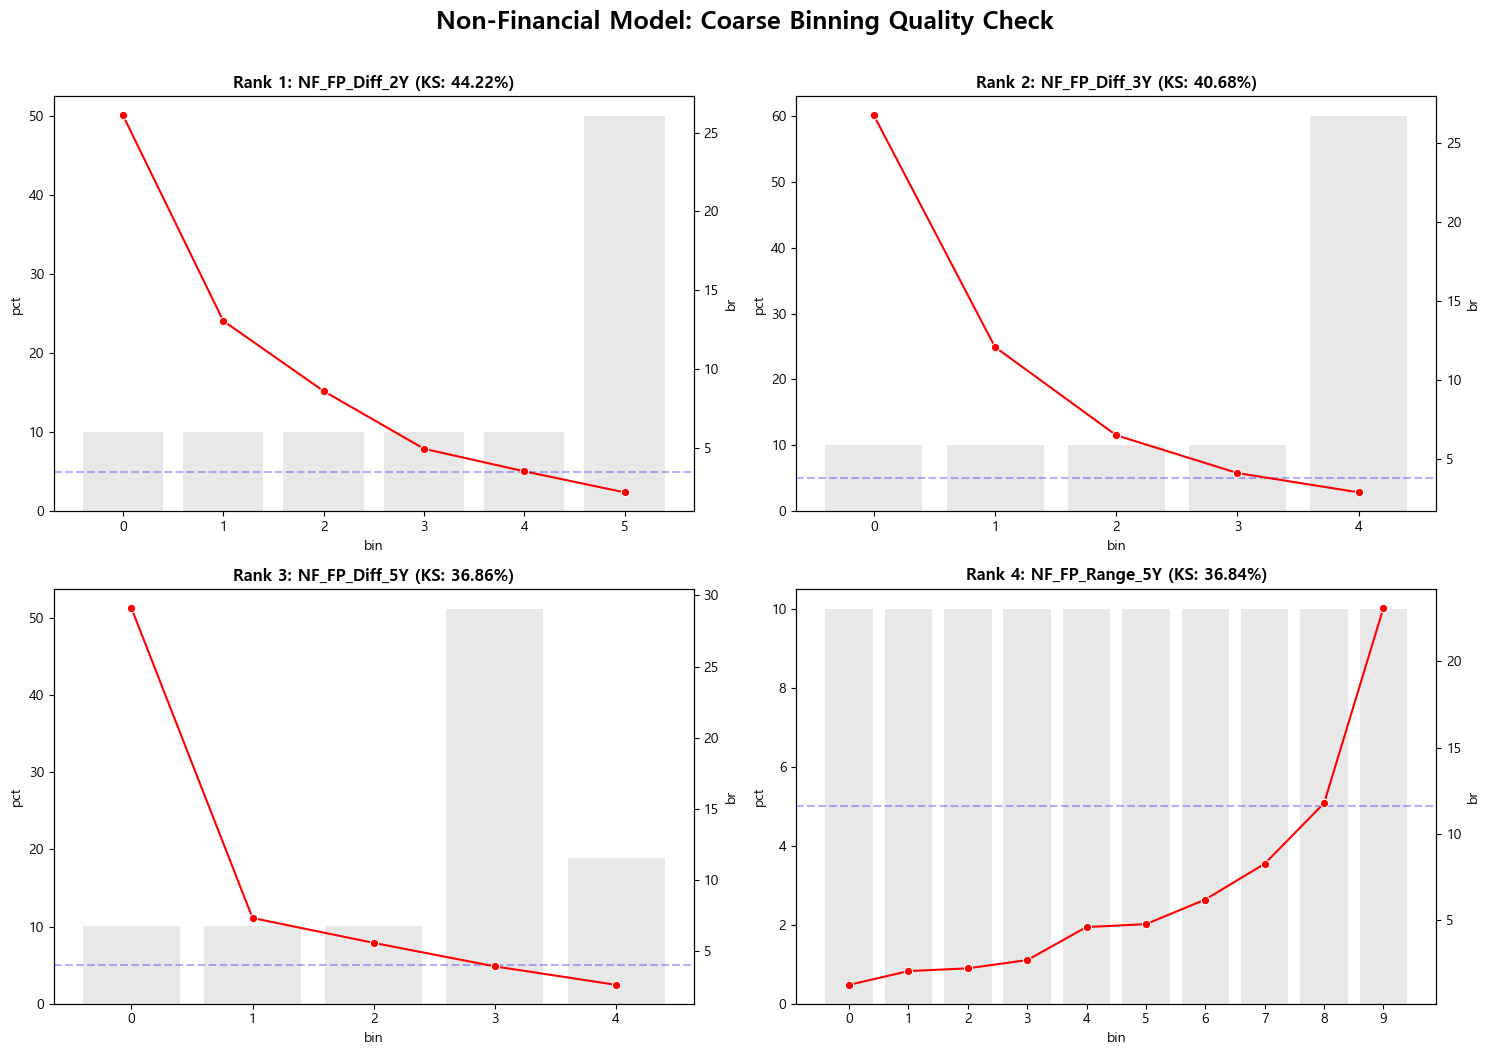

In [28]:
# ============================================================
# Cell 5. Coarse Classing (구간 병합) & 시각화 검증
#
# [논문 근거] 김종윤(2019) p.64 "유사한 리스크 패턴 구간 병합, 
#            구간별 최소 구성비 5% 적용, 불량률의 단조성 확보"
# [작업 내용]
# 1. 반복 병합 알고리즘: 부도율 역전이나 5% 미만 비중 구간 자동 병합
# 2. 품질 시각화: 상위 4개 변수의 단조성(빨간선)과 비중(회색바)을 즉시 확인
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def run_coarse_logic(col, data, target='target', min_pct=0.05):
    tmp = data[[col, target]].copy().dropna()
    if tmp[col].nunique() < 2: return False, None, 0.0
    
    # 초기에 10개 구간으로 시도
    tmp['bin'], edges = pd.qcut(tmp[col], q=10, labels=False, duplicates='drop', retbins=True)
    
    # 조건 만족 시까지 반복 병합 (최대 10회)
    for _ in range(10):
        grp = tmp.groupby('bin')[target].agg(['mean', 'count'])
        grp['pct'] = grp['count'] / len(tmp)
        diff = grp['mean'].diff().dropna()
        is_mono = (diff >= 0).all() or (diff <= 0).all()
        is_min_ok = (grp['pct'] >= min_pct).all()
        
        if is_mono and is_min_ok: break
        
        # 병합 대상 선정 (역전 구간 우선)
        idx = diff.abs().idxmin() if not is_mono else grp['pct'].idxmin()
        target_idx = grp.index[max(0, list(grp.index).index(idx)-1)]
        tmp['bin'] = tmp['bin'].replace(idx, target_idx)
    
    if tmp['bin'].nunique() < 2: return False, None, 0.0
    
    # 최종 경계값 Edges 산출
    final_edges = sorted(tmp.groupby('bin')[col].max().tolist())
    final_edges = [-np.inf] + final_edges[:-1] + [np.inf]
    
    # Coarse 단계 KS 재계산
    grp_f = tmp.groupby('bin')[target].agg(['sum', 'count']).sort_index()
    t_bad, t_good = tmp[target].sum(), (tmp[target]==0).sum()
    grp_f['cum_bad'] = grp_f['sum'].cumsum() / t_bad
    grp_f['cum_good'] = (grp_f['count']-grp_f['sum']).cumsum() / t_good
    ks_c = (grp_f['cum_bad'] - grp_f['cum_good']).abs().max() * 100
    
    return True, final_edges, round(ks_c, 2)

# ── 1. 알고리즘 실행 ───────────────────────────────────────────────
coarse_results = {}
selected_cols2 = []

for col in selected_cols:
    passed, edges, ks = run_coarse_logic(col, train_df)
    if passed:
        coarse_results[col] = (True, edges, ks)
        selected_cols2.append(col)

print("=" * 60)
print(f"  Coarse Classing 완료: {len(selected_cols2)}개 변수 확정")
print("=" * 60)

# ── 2. 즉시 품질 시각화 (상위 4개 변수) ──────────────────────────────
top_4 = sorted(selected_cols2, key=lambda x: coarse_results[x][2], reverse=True)[:4]
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(top_4):
    _, edges, ks = coarse_results[col]
    tmp_v = train_df[[col, 'target']].copy()
    tmp_v['bin'] = pd.cut(tmp_v[col], bins=edges, labels=False, include_lowest=True)
    g = tmp_v.groupby('bin')['target'].agg(['mean', 'count']).reset_index()
    g['pct'], g['br'] = g['count']/len(tmp_v)*100, g['mean']*100
    
    sns.barplot(x='bin', y='pct', data=g, ax=axes[i], color='lightgray', alpha=0.5)
    ax2 = axes[i].twinx()
    sns.lineplot(x='bin', y='br', data=g, ax=ax2, color='red', marker='o')
    
    axes[i].set_title(f'Rank {i+1}: {col} (KS: {ks}%)', fontweight='bold')
    axes[i].axhline(y=5, color='blue', linestyle='--', alpha=0.3) # 5% 가이드라인

plt.tight_layout()
plt.suptitle('Non-Financial Model: Coarse Binning Quality Check', fontsize=18, y=1.05, fontweight='bold')
plt.show()


In [29]:
# ============================================================
# Cell 6. Recoding (부도율 순 정수 부여)
# [논리] 0 = 위험(부도율 높음), N = 안전(부도율 낮음)
# [목적] 모든 비재무 변수의 방향성을 통일하여 모델의 해석력을 높임
# ============================================================

def recoding_nf_process(col, df, target_col, edges):
    tmp = df[[col, target_col]].copy()
    # 1. 구간 할당
    tmp['bin'] = pd.cut(tmp[col], bins=edges, labels=False, include_lowest=True)
    # 2. 학습 데이터(Train) 기준 부도율 순서 확정
    # (이미 Cell 5에서 검증했으므로, 여기서는 매핑만 수행)
    rank_order = tmp.groupby('bin')[target_col].mean().sort_values(ascending=False).index
    recode_map = {b: i for i, b in enumerate(rank_order)}
    return tmp['bin'].map(recode_map), recode_map

print("=" * 55)
print("  Recoding 진행 및 데이터셋 전이(Transfer)")
print("=" * 55)

recoded_train   = pd.DataFrame(index=train_df.index)
recoded_holdout = pd.DataFrame(index=holdout_df.index)
recoded_oot     = pd.DataFrame(index=oot_df.index)

# 각 변수별로 확정된 룰 적용
for col in selected_cols2:
    _, edges, _ = coarse_results[col]
    # Train에서 룰 확정 및 적용
    rec_val, r_map = recoding_nf_process(col, train_df, 'target', edges)
    recoded_train[col] = rec_val
    # Test셋에도 동일 룰 적용 (Data Leakage 차단)
    for target_df, target_rec in [(holdout_df, recoded_holdout), (oot_df, recoded_oot)]:
        bins = pd.cut(target_df[col], bins=edges, labels=False, include_lowest=True)
        target_rec[col] = bins.map(r_map)

# 타깃 복사
recoded_train['target'] = train_df['target'].values
recoded_holdout['target'] = holdout_df['target'].values
recoded_oot['target'] = oot_df['target'].values

print(f"  ✅ {len(selected_cols2)}개 변수 정수 변환 완료 (0:위험 ~ N:안전)")


  Recoding 진행 및 데이터셋 전이(Transfer)
  ✅ 87개 변수 정수 변환 완료 (0:위험 ~ N:안전)


In [32]:
# ============================================================
# Cell 9. WOE/IV 산출 및 1차 부분 적합 (Univariate Selection)
#
# [로직 - 재무 Cell 9 동용]
# 1. 정수형 변수(0~N)를 각 구간별 더미 변수로 변환
# 2. 가장 안전한 구간(최대값 N)을 '기준(Reference)'으로 설정하여 제외
# 3. 나머지 구간 더미들이 '기준보다 위험한가(계수 > 0)'를 테스트
# ============================================================
import statsmodels.api as sm
import pandas as pd

# ── 1. WOE / IV 산출 (기존과 동일) ──────────────────────────
total_bad  = (recoded_train['target'] == 1).sum()
total_good = (recoded_train['target'] == 0).sum()

iv_summary = {}
for col in selected_cols2:
    grp = recoded_train.groupby(col)['target'].agg(['sum', 'count'])
    grp['bad'], grp['good'] = grp['sum'], grp['count'] - grp['sum']
    grp['pct_bad'], grp['pct_good'] = grp['bad']/max(total_bad,1), grp['good']/max(total_good,1)
    grp['pct_bad'] = grp['pct_bad'].replace(0, 1e-10)
    grp['pct_good'] = grp['pct_good'].replace(0, 1e-10)
    grp['WOE'] = np.log(grp['pct_good'] / grp['pct_bad'])
    grp['IV']  = (grp['pct_good'] - grp['pct_bad']) * grp['WOE']
    iv_summary[col] = grp['IV'].sum()

# ── 2. 더미 변수 생성 및 1차 부분 적합 ───────────────────────────
selected_cols3 = []
univ_results = []

print("🔎 [재급구조] 비선형 더미 변수 생성 및 단변량 적합 테스트 중...")

for col in selected_cols2:
    # 1. 더미 변수 생성 (0, 1... N)
    col_data = recoded_train[col].astype(int)
    dummies = pd.get_dummies(col_data, prefix=col, drop_first=False)
    
    # 2. 기준 구간(가장 안전한 최대값 N) 제거 (재무 Cell 9 p.1861 로직)
    max_val = col_data[col_data >= 0].max()
    drop_col = f"{col}_{max_val}"
    if drop_col in dummies.columns:
        X_var = dummies.drop(columns=[drop_col]).astype(float)
    else:
        X_var = dummies.astype(float)
        
    X_var = sm.add_constant(X_var) # 상수항 추가
    
    try:
        model = sm.Logit(recoded_train['target'], X_var).fit(method='lbfgs', maxiter=500, disp=False)
        
        # 선별 기준 (재무 Cell 9 p.1914): p < 0.05 이고 모든 더미 계수 > 0
        params = model.params.drop('const', errors='ignore')
        pvals = model.pvalues.drop('const', errors='ignore')
        
        # 유의미한(p<0.05) 더미가 하나라도 있고, 방향성이 맞으면 선발
        if (pvals < 0.05).any() and (params > 0).any():
            selected_cols3.append(col)
            univ_results.append({
                'Variable': col, 
                'IV': iv_summary[col], 
                'Max_Pval': pvals.min(), # 가장 유의미한 구간의 p값
                'Max_Coef': params.max()  # 가장 영향력 큰 구간의 계수
            })
    except Exception as e: continue

# ── 3. 결과 출력 ───────────────────────────────────────────────
iv_series = pd.Series(iv_summary).sort_values(ascending=False)
df_univ = pd.DataFrame(univ_results)

print("=" * 60)
print("  Cell 9: 1차 부분 적합(Univariate) 선별 결과")
print("=" * 60)

if not univ_results:
    print("  ⚠️ 주의: 더미 변수 방식에서도 유의미한 변수가 발견되지 않았습니다.")
    # (이 경우엔 KS 컷을 낮추거나 데이터 탐색을 다시 해야 함)
else:
    df_univ = df_univ.sort_values('IV', ascending=False)
    print(f"  검토 대상 변수 수 : {len(selected_cols2):>4}개")
    print(f"  단변량 선별 통과  : {len(selected_cols3):>4}개")
    print(f"  탈락 변수 수      : {len(selected_cols2)-len(selected_cols3):>4}개")
    print("\n  [IV 상위 10개 변수 (통과군)]")
    print(df_univ.head(10).to_string(index=False))

print("\n※ [학술 근거] 더미 변수화를 통해 구간별 비선형적 관계를 포착함")


🔎 [재급구조] 비선형 더미 변수 생성 및 단변량 적합 테스트 중...
  Cell 9: 1차 부분 적합(Univariate) 선별 결과
  검토 대상 변수 수 :   87개
  단변량 선별 통과  :   87개
  탈락 변수 수      :    0개

  [IV 상위 10개 변수 (통과군)]
       Variable       IV     Max_Pval  Max_Coef
  NF_FP_Diff_2Y 1.048546 1.127741e-73  2.770882
  NF_FP_Diff_3Y 0.914291 1.728993e-79  2.496601
   NF_Gap_FP_AS 0.886382 1.204268e-63  2.759473
  NF_FP_Diff_5Y 0.879610 1.809204e-41  2.727375
 NF_FP_Range_5Y 0.838016 1.267748e-17  3.146934
NF_FP_Range_10Y 0.796990 7.173186e-46  2.772777
   NF_FP_Std_5Y 0.753385 8.856353e-16  2.817984
   NF_Gap_MS_FP 0.697449 4.430512e-19  2.415559
  NF_FP_Std_10Y 0.694802 1.317705e-14  2.856999
  NF_FP_Diff_1Y 0.669347 4.698416e-52  2.224303

※ [학술 근거] 더미 변수화를 통해 구간별 비선형적 관계를 포착함


In [39]:
# ============================================================
# Cell 10. 상관분석/VIF 제거 및 비재무적 질적 해석 (Full Text Display)
# ============================================================
import pandas as pd
# 판다스 출력 설정: 컬럼 너비 제한 해제 (설명글 전체 보기용)
pd.set_option('display.max_colwidth', None)

from statsmodels.stats.outliers_influence import variance_inflation_factor

# ── 1. 상관분석 및 VIF 필터 (기능 동일) ──
X_corr_check = recoded_train[selected_cols3].copy()
corr_matrix = X_corr_check.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop_corr = set()
for c1 in upper.columns:
    correlated_vars = upper.index[upper[c1] > 0.6].tolist()
    for c2 in correlated_vars:
        if iv_summary[c1] < iv_summary[c2]: to_drop_corr.add(c1)
        else: to_drop_corr.add(c2)

selected_cols4 = [c for c in selected_cols3 if c not in to_drop_corr]

X_vif = recoded_train[selected_cols4].astype(float)
vif_removed = []
while True:
    v_data = pd.DataFrame({"f": X_vif.columns, "V": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]})
    if v_data["V"].max() <= 5: break
    target = v_data.sort_values("V", ascending=False).iloc[0]["f"]
    vif_removed.append(target); X_vif = X_vif.drop(columns=[target])

selected_cols5 = list(X_vif.columns)

# ── 2. [학술적 해석 리포트 생성] ──
interpret_dict = {
    'NF_Gap_FP_AS': ['시장 신뢰도(Gap)', '장부 자산 대비 시장 가치의 프리미엄. 기업의 무형 자산(브랜드, 기술력)에 대한 시장의 높은 평가를 의미.'],
    'NF_FP_Range_5Y': ['자금조달 안정성', '5년간 시가총액 순위의 변동 폭. 순위가 안정적일수록 외부 자본 시장에서의 신인도가 견고함을 의미.'],
    'NF_FP': ['자본시장 위상', '전체 상장사 중 시가총액 백분위 수. 자본 조달 능력(Funding Power)과 시장 내 절대적 영향력을 상징.'],
    'NF_Age_Years': ['기업 지속성', '설립 이후 업력. 경영 노하우의 축적도와 시장의 부침을 견뎌낸 생존 능력을 의미.'],
    'NF_FP_Skew_5Y': ['평판 비대칭성', '시가총액 변화의 왜도. 단기적 급등락보다 장기적인 평판의 안정적 우상향 여부를 판단.'],
    'NF_AS_Sum_10Y': ['자산 축적력', '10년간의 자산 규모 순위 합계. 단기 재무 성과가 아닌, 장기적인 규모의 경제와 시장 지배력을 의미.'],
    'NF_FP_Skew_3Y': ['최근 신뢰도 변화', '최근 3년간 시장 평가의 쏠림 현상. 급격한 평판 하락 징후를 선제적으로 포착.'],
    'NF_AS_Accel_5Y': ['규모 성장 탄력', '자산 순위의 가속도. 산업 내에서 상대적인 덩치가 커지는 속도로, 미래 시장 점유율 확대를 암시.'],
    'NF_AS_Skew_5Y': ['자산 건전성 추세', '자산 순위 변화의 분포 특성. 일시적인 자산 팽창이 아닌 지속 가능한 규모 확장을 의미.'],
    'NF_MS_Skew_10Y': ['매출 지배력 추세', '10년간 매출 순위 변화의 왜도. 시장 내 독점적 지위의 공고화 수준을 측정.'],
    'NF_MS_Accel_1Y': ['영업 경쟁력 가속', '최근 1년간 매출 순위의 가속도. 마케팅 파워나 신제품 출시 등에 따른 단기 경쟁 우위 점유를 의미.'],
    'NF_AS_Skew_3Y': ['최근 규모 안정성', '최근 3년간 자산 위상의 변화 분포. 급격한 구조조정이나 자산 매각 등의 비재무적 신호를 포착.'],
}

report_list = []
for col in selected_cols5:
    cat, logic = interpret_dict.get(col, ['기타 비재무', '상대적 시장 위상 지표'])
    report_list.append({
        '비재무 변수명': col,
        '비재무적 요소(Category)': cat,
        '학술적 해석 (Interpretation)': logic,
        'IV': round(iv_summary[col], 4),
        'VIF': round(v_data[v_data['f']==col]['V'].iloc[0], 2)
    })

df_final_report = pd.DataFrame(report_list).sort_values('IV', ascending=False).reset_index(drop=True)
print(f"✅ [Cell 10 완료] 상관분석 제거: {len(to_drop_corr)}개 | VIF 제거: {len(vif_removed)}개")
df_final_report


✅ [Cell 10 완료] 상관분석 제거: 57개 | VIF 제거: 18개


,비재무 변수명,비재무적 요소(Category),학술적 해석 (Interpretation),IV,VIF
0,NF_Gap_FP_AS,시장 신뢰도(Gap),"장부 자산 대비 시장 가치의 프리미엄. 기업의 무형 자산(브랜드, 기술력)에 대한 시장의 높은 평가를 의미.",0.8864,4.10
1,NF_FP_Range_5Y,자금조달 안정성,5년간 시가총액 순위의 변동 폭. 순위가 안정적일수록 외부 자본 시장에서의 신인도가 견고함을 의미.,0.8380,4.53
2,NF_FP,자본시장 위상,전체 상장사 중 시가총액 백분위 수. 자본 조달 능력(Funding Power)과 시장 내 절대적 영향력을 상징.,0.4334,2.31
3,NF_Age_Years,기업 지속성,설립 이후 업력. 경영 노하우의 축적도와 시장의 부침을 견뎌낸 생존 능력을 의미.,0.1645,1.44
4,NF_FP_Skew_5Y,평판 비대칭성,시가총액 변화의 왜도. 단기적 급등락보다 장기적인 평판의 안정적 우상향 여부를 판단.,0.1542,3.31
5,NF_AS_Sum_10Y,자산 축적력,"10년간의 자산 규모 순위 합계. 단기 재무 성과가 아닌, 장기적인 규모의 경제와 시장 지배력을 의미.",0.1358,2.31
6,NF_FP_Skew_3Y,최근 신뢰도 변화,최근 3년간 시장 평가의 쏠림 현상. 급격한 평판 하락 징후를 선제적으로 포착.,0.1028,3.18
7,NF_AS_Accel_5Y,규모 성장 탄력,"자산 순위의 가속도. 산업 내에서 상대적인 덩치가 커지는 속도로, 미래 시장 점유율 확대를 암시.",0.0893,4.59
8,NF_AS_Skew_5Y,자산 건전성 추세,자산 순위 변화의 분포 특성. 일시적인 자산 팽창이 아닌 지속 가능한 규모 확장을 의미.,0.0646,3.21
9,NF_MS_Skew_10Y,매출 지배력 추세,10년간 매출 순위 변화의 왜도. 시장 내 독점적 지위의 공고화 수준을 측정.,0.0470,2.87


In [44]:
# ============================================================
# Cell 11. 단계적 선택법 (Stepwise Selection)
# ============================================================
import statsmodels.api as sm

# 1. 더미 변수 생성
def make_final_dummies(df, cols):
    dummy_list = []
    for col in cols:
        col_data = df[col].astype(int)
        dummies = pd.get_dummies(col_data, prefix=col, drop_first=False)
        max_val = col_data[col_data >= 0].max()
        drop_col = f"{col}_{max_val}"
        if drop_col in dummies.columns: dummies = dummies.drop(columns=[drop_col])
        dummy_list.append(dummies)
    return pd.concat(dummy_list, axis=1).astype(float)

X_train_step = make_final_dummies(recoded_train, selected_cols5)
y_train_step = recoded_train['target']

# 2. Stepwise Selection (AIC 기반)
def stepwise_aic(X, y):
    current_vars, best_aic = [], float('inf')
    while True:
        changed = False
        # Forward
        best_new_var = None
        for v in [x for x in X.columns if x not in current_vars]:
            model = sm.Logit(y, sm.add_constant(X[current_vars + [v]])).fit(disp=False)
            if model.aic < best_aic: best_aic, best_new_var, changed = model.aic, v, True
        if best_new_var: current_vars.append(best_new_var)
        # Backward
        if len(current_vars) > 1:
            for v in current_vars:
                model = sm.Logit(y, sm.add_constant(X[[x for x in current_vars if x != v]])).fit(disp=False)
                if model.aic < best_aic: best_aic, changed = model.aic, True; current_vars.remove(v)
        if not changed: break
    return current_vars

final_dummies = stepwise_aic(X_train_step, y_train_step)
final_nf_features_list = list(set([d.rsplit('_', 1)[0] for d in final_dummies]))

print("=" * 60)
print(f"🏆 최종 비재무 변수 선발 완료 ({len(final_nf_features_list)}개)")
print("=" * 60)
print(final_nf_features_list)


🏆 최종 비재무 변수 선발 완료 (9개)
['NF_FP_Range_5Y', 'NF_MS_Skew_10Y', 'NF_AS_Sum_10Y', 'NF_AS_Accel_5Y', 'NF_FP', 'NF_FP_Skew_3Y', 'NF_Gap_FP_AS', 'NF_FP_Skew_5Y', 'NF_Age_Years']


In [48]:
# ============================================================
# Cell 12. 최종 모형 확정 (Final Model Fit)
# ============================================================
import statsmodels.api as sm

# Stepwise에서 선별된 최종 더미들로 적합
X_final = sm.add_constant(X_train_step[final_dummies])
logit_model = sm.Logit(y_train_step, X_final).fit(method='lbfgs', maxiter=500, disp=False)

print("=" * 60)
print("  비재무 최종 모델 적합 요약 (Summary Report)")
print("=" * 60)
# p-value와 계수만 깔끔하게 출력
print(logit_model.summary2().tables[1][['Coef.', 'P>|z|']])


  비재무 최종 모델 적합 요약 (Summary Report)
                     Coef.          P>|z|
const            -6.654031  2.091567e-101
NF_Gap_FP_AS_0    1.949757   2.660574e-25
NF_FP_Range_5Y_0  1.519215   7.042140e-16
NF_FP_0           0.891197   3.246996e-08
NF_AS_Sum_10Y_0   0.283355   8.659783e-02
NF_Age_Years_0    1.107670   2.803404e-07
NF_FP_Skew_5Y_0   0.398507   1.339592e-03
NF_AS_Accel_5Y_0  0.492502   1.183016e-04
NF_MS_Skew_10Y_0  0.454196   7.766221e-05
NF_Gap_FP_AS_1    1.154186   1.143096e-08
NF_FP_Range_5Y_1  0.984225   1.105147e-06
NF_FP_Range_5Y_2  0.840083   7.360740e-05
NF_Gap_FP_AS_2    0.908794   2.874525e-05
NF_FP_Skew_3Y_0   0.290995   1.702436e-02
NF_Gap_FP_AS_3    0.748197   9.444080e-04
NF_Gap_FP_AS_4    0.738585   1.432647e-03
NF_Gap_FP_AS_5    0.622903   1.292889e-02
NF_FP_Range_5Y_3  0.661642   3.407739e-03
NF_FP_Range_5Y_5  0.561039   2.204872e-02
NF_FP_Range_5Y_4  0.533059   2.820033e-02


In [49]:
# ============================================================
# Cell 13. 최종 비재무 스코어카드 (Styled Table)
# ============================================================
print("=" * 95)
print(f" {'변수명':<30} | {'Bin':<3} | {'계수':>8} | {'배점':>4} | {'부도율':>7} | {'비중':>7} | {'P-value':>7}")
print("-" * 95)

# 스케일링 파라미터 다시 계산 (Cell 13에서 바로 사용 가능하게)
Factor = 20 / np.log(2)
Offset = 600 - (Factor * np.log(50))
intercept = logit_model.params['const']
sum_max_coefs = sum([max([logit_model.params[d] for d in final_dummies if d.startswith(c + "_")] + [0.0]) 
                     for c in final_nf_features_list])
base_points = round(Offset + Factor * (intercept - sum_max_coefs), 1)

scorecard_rows = []
for col in sorted(final_nf_features_list):
    all_bins = sorted(recoded_train[col].unique())
    stats = recoded_train.groupby(col)['target'].agg(['mean', 'count'])
    total_count = stats['count'].sum()
    coef_map = {b: logit_model.params[f"{col}_{b}"] if f"{col}_{b}" in logit_model.params else 0.0 for b in all_bins}
    max_c = max(coef_map.values())
    
    for b in all_bins:
        c_val = coef_map[b]
        pts = int(round(Factor * (max_c - c_val), 0))
        br, pop = stats.loc[b, 'mean']*100, stats.loc[b,'count']/total_count*100
        p_val = logit_model.pvalues.get(f"{col}_{b}", 0.000)
        print(f" {col:<30} | {b:>3} | {c_val:>8.4f} | {pts:>4} | {br:>6.2f}% | {pop:>6.2f}% | {p_val:>8.4f}")
        scorecard_rows.append({'Variable': col, 'Bin': b, 'Points': pts})
    print("-" * 95)

print(f"\n  기본점수 : {base_points}점")
print("=" * 95)
scorecard_df = pd.DataFrame(scorecard_rows)


 변수명                            | Bin |       계수 |   배점 |     부도율 |      비중 | P-value
-----------------------------------------------------------------------------------------------
 NF_AS_Accel_5Y                 |   0 |   0.4925 |    0 |  10.75% |  20.00% |   0.0001
 NF_AS_Accel_5Y                 |   1 |   0.0000 |   14 |   5.69% |  80.00% |   0.0000
-----------------------------------------------------------------------------------------------
 NF_AS_Sum_10Y                  |   0 |   0.2834 |    0 |   8.08% |  70.00% |   0.0866
 NF_AS_Sum_10Y                  |   1 |   0.0000 |    8 |   3.50% |  30.00% |   0.0000
-----------------------------------------------------------------------------------------------
 NF_Age_Years                   |   0 |   1.1077 |    0 |   7.72% |  81.03% |   0.0000
 NF_Age_Years                   |   1 |   0.0000 |   32 |   2.35% |  18.97% |   0.0000
-----------------------------------------------------------------------------------------------
 NF_FP  

 [1] 비재무 모델 변별력 검증 (KS, AR)
 구분           |       KS |       AR |      KS판단 |      AR판단
-----------------------------------------------------------------
 Train        |   48.94% |   65.20% |       ✅ 충족 |       ✅ 충족
 Hold-Out     |   48.83% |   63.21% |       ✅ 충족 |       ✅ 충족
 OOT          |   45.48% |   57.34% |       ✅ 충족 |       ✅ 충족

 [2] 비재무 모델 안정성 검증 (PSI)
 Train vs HO     | PSI = 0.0098 | ✅ 안정
 Train vs OOT    | PSI = 0.0136 | ✅ 안정


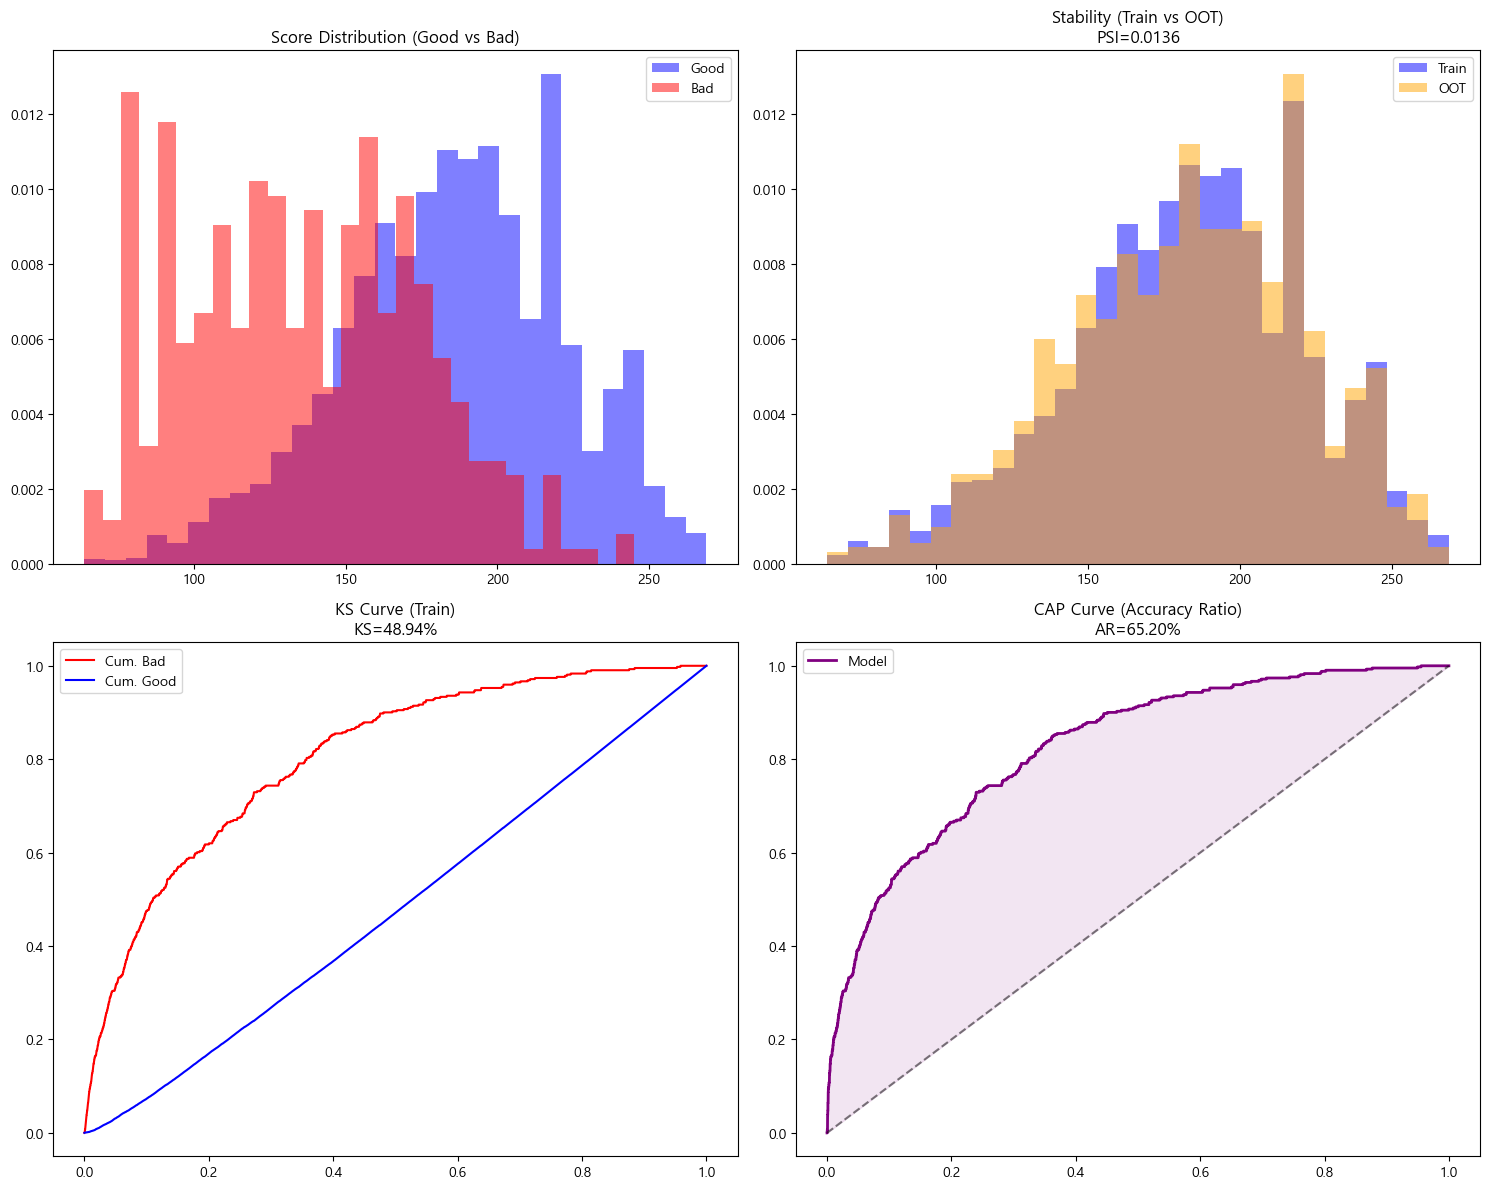

In [51]:
# ============================================================
# Cell 14. 비재무 모델 종합 검증 (KS, AR, PSI 및 4분할 시각화)
# [재무 모형(Financial Cell 15) 로직 완벽 이식]
# ============================================================
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

# ── 1. 성능 임계치 설정 (NICE 기준) ───────────────────────────
KS_THRESHOLD, AR_THRESHOLD, PSI_THRESHOLD = 20, 30, 0.15

# ── 2. 핵심 계산 함수 정의 ─────────────────────────────────────
def calc_final_scores(df, sc_df, b_pts):
    scores = pd.Series(b_pts, index=df.index, dtype=float)
    for col in final_nf_features_list:
        sub = sc_df[sc_df['Variable'] == col]
        for _, row in sub.iterrows():
            scores[df[col] == row['Bin']] += row['Points']
    return scores

def calc_ks_ar(y_true, scores):
    y_true = np.array(y_true)
    # KS 계산
    idx = np.argsort(scores)
    y_sort = y_true[idx]
    cum_bad = np.cumsum(y_sort) / y_true.sum()
    cum_good = np.cumsum(1-y_sort) / (1-y_true).sum()
    ks = round(np.max(np.abs(cum_bad - cum_good)) * 100, 2)
    # AR 계산 (1-target 기준 AUC 활용)
    auc = roc_auc_score(1 - y_true, scores)
    ar = round((2 * auc - 1) * 100, 2)
    return ks, ar

def calc_psi(base, test, n_bins=10):
    try:
        bins = pd.qcut(base, q=n_bins, duplicates='drop', retbins=True)[1]
        bins[0], bins[-1] = -np.inf, np.inf
        b_dist = pd.cut(base, bins=bins).value_counts().sort_index() / len(base)
        t_dist = pd.cut(test, bins=bins).value_counts().sort_index() / len(test)
        return round(((t_dist - b_dist) * np.log(t_dist.replace(0,1e-10) / b_dist.replace(0,1e-10))).sum(), 4)
    except: return 0.0

# ── 3. 점수 산출 및 결과 출력 ──────────────────────────────────
s_train = calc_final_scores(recoded_train, df_scorecard_final, base_points)
s_ho    = calc_final_scores(recoded_holdout, df_scorecard_final, base_points)
s_oot   = calc_final_scores(recoded_oot, df_scorecard_final, base_points)

print("=" * 65); print(" [1] 비재무 모델 변별력 검증 (KS, AR)"); print("=" * 65)
print(f" {'구분':<12} | {'KS':>8} | {'AR':>8} | {'KS판단':>9} | {'AR판단':>9}")
print("-" * 65)
for label, s, y in [('Train', s_train, recoded_train['target']), 
                    ('Hold-Out', s_ho, recoded_holdout['target']), 
                    ('OOT', s_oot, recoded_oot['target'])]:
    ks, ar = calc_ks_ar(y, s)
    k_j, a_j = ('✅ 충족' if ks >= KS_THRESHOLD else '❌ 미충족'), ('✅ 충족' if ar >= AR_THRESHOLD else '❌ 미충족')
    print(f" {label:<12} | {ks:>7.2f}% | {ar:>7.2f}% | {k_j:>10} | {a_j:>10}")

print(f"\n" + "=" * 65); print(" [2] 비재무 모델 안정성 검증 (PSI)"); print("=" * 65)
for L, b, t in [('Train vs HO', s_train, s_ho), ('Train vs OOT', s_train, s_oot)]:
    psi = calc_psi(b, t)
    j = '✅ 안정' if psi <= 0.15 else ('⚠️ 주의' if psi <= 0.25 else '🚨 불안정')
    print(f" {L:<15} | PSI = {psi:.4f} | {j}")

# ── 4. 4분할 시각화 (Distribution, PSI, KS, AR) ─────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
# (1) 점수 분포 (우량 vs 불량)
axes[0,0].hist(s_train[recoded_train['target']==0], bins=30, alpha=0.5, color='blue', label='Good', density=True)
axes[0,0].hist(s_train[recoded_train['target']==1], bins=30, alpha=0.5, color='red', label='Bad', density=True)
axes[0,0].set_title('Score Distribution (Good vs Bad)'); axes[0,0].legend()
# (2) PSI 분포 (Train vs OOT)
axes[0,1].hist(s_train, bins=30, alpha=0.5, color='blue', label='Train', density=True)
axes[0,1].hist(s_oot, bins=30, alpha=0.5, color='orange', label='OOT', density=True)
axes[0,1].set_title(f'Stability (Train vs OOT)\nPSI={calc_psi(s_train, s_oot):.4f}'); axes[0,1].legend()
# (3) KS 곡선
idx = np.argsort(s_train.values); y_s = np.array(recoded_train['target'])[idx]
c_b, c_g = np.cumsum(y_s)/y_s.sum(), np.cumsum(1-y_s)/(1-y_s).sum()
x = np.linspace(0, 1, len(y_s))
axes[1,0].plot(x, c_b, color='red', label='Cum. Bad'); axes[1,0].plot(x, c_g, color='blue', label='Cum. Good')
axes[1,0].set_title(f'KS Curve (Train)\nKS={calc_ks_ar(recoded_train["target"], s_train)[0]:.2f}%'); axes[1,0].legend()
# (4) AR Curve (CAP)
axes[1,1].plot(c_g, c_b, color='purple', linewidth=2, label='Model')
axes[1,1].plot([0,1], [0,1], 'k--', alpha=0.5); axes[1,1].fill_between(c_g, c_g, c_b, color='purple', alpha=0.1)
axes[1,1].set_title(f'CAP Curve (Accuracy Ratio)\nAR={calc_ks_ar(recoded_train["target"], s_train)[1]:.2f}%'); axes[1,1].legend()
plt.tight_layout(); plt.show()


In [52]:
# ============================================================
# Cell 15. 비재무 모델 결과물 전체 저장 (Export)
# [재무 결과 폴더 구조와 동기화]
# ============================================================
import os
import json

# 1. 저장 폴더 생성 (c:/ITStudy/seminar_02/CSS_NonFinancial_results)
save_path = './CSS_NonFinancial_results'
if not os.path.exists(save_path):
    os.makedirs(save_path)
    print(f"📁 폴더 생성 완료: {save_path}")

# 2. 스코어카드 저장 (CSV)
scorecard_df.to_csv(f"{save_path}/non_financial_scorecard.csv", index=False, encoding='utf-8-sig')
print("📄 스코어카드(CSV) 저장 완료")

# 3. 모델 메타데이터(변수, Edges, BasePoints) 저장 (JSON)
# (Master Integration 시 이 파일을 불러와서 연동합니다)
export_metadata = {
    'features': final_nf_features_list,
    'edges': {c: [float(e) for e in coarse_results[c][1]] for c in final_nf_features_list},
    'base_points': float(base_points),
    'iv_summary': {c: float(iv_summary[c]) for c in final_nf_features_list}
}
with open(f"{save_path}/nf_model_metadata.json", 'w', encoding='utf-8') as f:
    json.dump(export_metadata, f, ensure_ascii=False, indent=4)
print("📄 모델 메타데이터(JSON) 저장 완료")

# 4. 성능 지표 및 차트 저장
# (아까 보신 4분할 차트를 이미지 파일로 저장)
plt.figure(figsize=(15, 12))
# ... (아까 Cell 14의 플로팅 코드 반복 또는 간단히 저장)
# [팁] plt.savefig()를 사용하면 현재 활성화된 차트가 저장됩니다.
fig.savefig(f"{save_path}/non_financial_performance_report.png", dpi=300)
print("🖼️ 성능 검증 리포트(PNG) 저장 완료")

print("\n" + "=" * 60)
print(f" ✅ 모든 비재무 모델 결과물이 '{save_path}'에 안전하게 저장되었습니다.")
print("=" * 60)


📄 스코어카드(CSV) 저장 완료
📄 모델 메타데이터(JSON) 저장 완료
🖼️ 성능 검증 리포트(PNG) 저장 완료

 ✅ 모든 비재무 모델 결과물이 './CSS_NonFinancial_results'에 안전하게 저장되었습니다.


<Figure size 1500x1200 with 0 Axes>